# CinCECGTorso: 4-class clustering of long ECG signals

UCR CinCECGTorso, 1420 single-lead ECG records of length
1639 from the Computers in Cardiology 2007 challenge, 4 balanced
classes (~355 records each) corresponding to recording-mode
categories.

Classes differ along two essentially
independent axes: morphology (waveform shape after z-normalisation)
and amplitude (peak-to-peak swing). 

`filt_shape` is L2 between z-normalised pairs (amplitude removed)

`filt_amp` is the peak-to-peak difference. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian

## Data

full set: N=1420 L=1639
subsample: N=200 L=1639, train=140 test=60
class counts (test): [15 15 15 15]


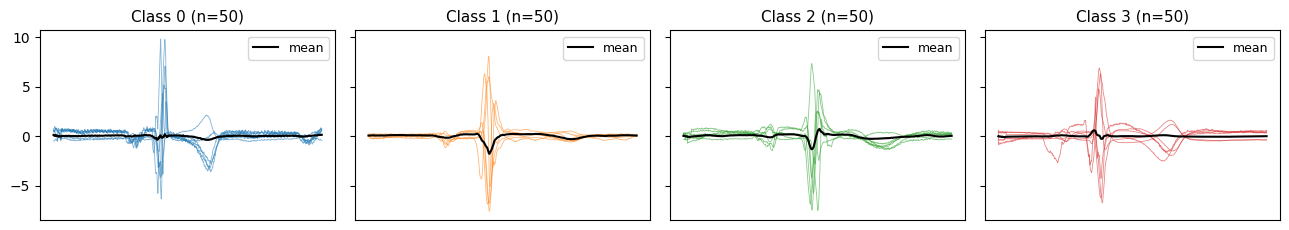

In [2]:
X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('CinCECGTorso')
X_full = np.vstack([X_tr.squeeze(-1), X_te.squeeze(-1)])
y_full = np.concatenate([y_tr, y_te]).astype(int) - 1
print(f"full set: N={len(X_full)} L={X_full.shape[1]}")

K_TRUE = 4
PER_CLASS = 50
rng = np.random.default_rng(42)
sel = []
for c in range(K_TRUE):
    idx_c = np.where(y_full == c)[0]
    sel.extend(rng.choice(idx_c, PER_CLASS, replace=False))
sel = np.array(sel); rng.shuffle(sel)
X = X_full[sel]; y_true = y_full[sel]
N, L = X.shape

all_idx = np.arange(N)
train_idx, test_idx = train_test_split(all_idx, test_size=0.30,
                                       stratify=y_true, random_state=42)
train_idx.sort(); test_idx.sort()
y_train = y_true[train_idx]; y_test = y_true[test_idx]
print(f"subsample: N={N} L={L}, train={len(train_idx)} test={len(test_idx)}")
print(f"class counts (test): {np.bincount(y_test)}")

CLASS_COLORS = ["C0", "C1", "C2", "C3"]
fig, axes = plt.subplots(1, K_TRUE, figsize=(13, 2.4), sharey=True)
for ax, c in zip(axes, range(K_TRUE)):
    for i in np.where(y_true == c)[0][:6]:
        ax.plot(X[i], color=CLASS_COLORS[c], lw=0.6, alpha=0.55)
    ax.plot(X[y_true == c].mean(0), color="k", lw=1.5, label="mean")
    ax.set_title(f"Class {c} (n={(y_true == c).sum()})", fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Filtrations

Six candidate axes are pre-computed; the main pair is `shape × amp`.

- `shape`   -- z-normalised waveform L2 (morphology, amplitude removed).
- `amp`     -- peak-to-peak difference.
- `raw`     -- raw waveform L2.
- `deriv`   -- first-difference L2 (smoothness).
- `spec`    -- FFT magnitude L2.
- `peakloc` -- |argmax_i − argmax_j| (R-peak position).

In [3]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
amp = X.max(1) - X.min(1)
dX = np.diff(X, axis=1)
spec = np.abs(np.fft.rfft(Xz))
peak_loc = np.argmax(X, axis=1).astype(float)

D_axes = {
    "shape": cdist(Xz, Xz),
    "amp": np.abs(amp[:, None] - amp[None, :]),
    "raw": cdist(X, X),
    "deriv": cdist(dX, dX),
    "spec": cdist(spec, spec),
    "peakloc": np.abs(peak_loc[:, None] - peak_loc[None, :]),
}
iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
F_axes = {k: assemble_filtration(N, edges, v[iu, ju]) for k, v in D_axes.items()}

filt_shape, filt_amp = F_axes["shape"], F_axes["amp"]

## Tuning

GMM on the engineered 2D features `(||z(x) − mean_z||, peak2peak)`

GMM with diagonal covariance on the raw 1639-d z-normalised series (full/tied are singular at this dimensionality with N=140 train)

KMeans on the same raw 1639-d series.

In [4]:
def tune_and_eval(name, configs):
    best_train, best_pred, best_label = -1.0, None, None
    for label, labels in configs:
        labels = np.asarray(labels)
        a = adjusted_rand_score(y_train, labels[train_idx])
        if a > best_train:
            best_train, best_pred, best_label = a, labels, label
    test_ari = adjusted_rand_score(y_test, best_pred[test_idx])
    test_nmi = normalized_mutual_info_score(y_test, best_pred[test_idx])
    return {"method": name, "best_config": best_label,
            "train_ARI": best_train, "test_ARI": test_ari,
            "test_NMI": test_nmi, "pred": best_pred}

def bif_configs(methods):
    cfgs = []
    for slope in [0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
        for k in [2, 3, 4, 5, 6]:
            for meth in methods:
                if meth == "simplify":
                    for ms in [2, 3, 5, 8, 12, 20]:
                        r = run_bifiltration_edges(N, filt_shape, filt_amp, method=meth,
                                                   n_clusters=k, slope=slope, min_size=ms)
                        cfgs.append((f"{meth} slope={slope} k={k} ms={ms}", r.labels_combined))
                else:
                    r = run_bifiltration_edges(N, filt_shape, filt_amp, method=meth,
                                               n_clusters=k, slope=slope)
                    cfgs.append((f"{meth} slope={slope} k={k}", r.labels_combined))
    return cfgs

shape_dist = np.linalg.norm(Xz - Xz.mean(0), axis=1)
feat = StandardScaler().fit_transform(np.column_stack([shape_dist, amp]))
feat_raw = Xz

gmm_cfgs = [(f"{cov} k={k}",
             GaussianMixture(n_components=k, covariance_type=cov, n_init=20,
                             max_iter=500, reg_covar=1e-4,
                             random_state=42).fit_predict(feat))
            for cov in ("full", "tied", "diag") for k in [2, 3, 4, 5]]
gmm_raw_cfgs = [(f"raw1639 diag k={k}",
                 GaussianMixture(n_components=k, covariance_type="diag",
                                 n_init=20, max_iter=500, reg_covar=1e-4,
                                 random_state=42).fit_predict(feat_raw))
                for k in [2, 3, 4, 5, 6]]
km_raw_cfgs = [(f"raw1639 k={k}",
                KMeans(n_clusters=k, n_init=50, max_iter=500,
                       random_state=42).fit_predict(feat_raw))
               for k in [2, 3, 4, 5, 6]]

results = [
    tune_and_eval("Bifiltration (persist)", bif_configs(("persistence",))),
    tune_and_eval("GMM 2D",  gmm_cfgs),
    tune_and_eval("GMM",     gmm_raw_cfgs),
    tune_and_eval("KMeans",  km_raw_cfgs),
]
df = pd.DataFrame([{k: v for k, v in r.items() if k != "pred"} for r in results])
df.sort_values("test_ARI", ascending=False).reset_index(drop=True).round(3)

,method,best_config,train_ARI,test_ARI,test_NMI
0,Bifiltration (persist),persistence slope=0.5 k=4,0.801,0.838,0.864
1,GMM,raw1639 diag k=5,0.334,0.399,0.590
2,GMM 2D,full k=5,0.268,0.278,0.364
3,KMeans,raw1639 k=6,0.277,0.231,0.402


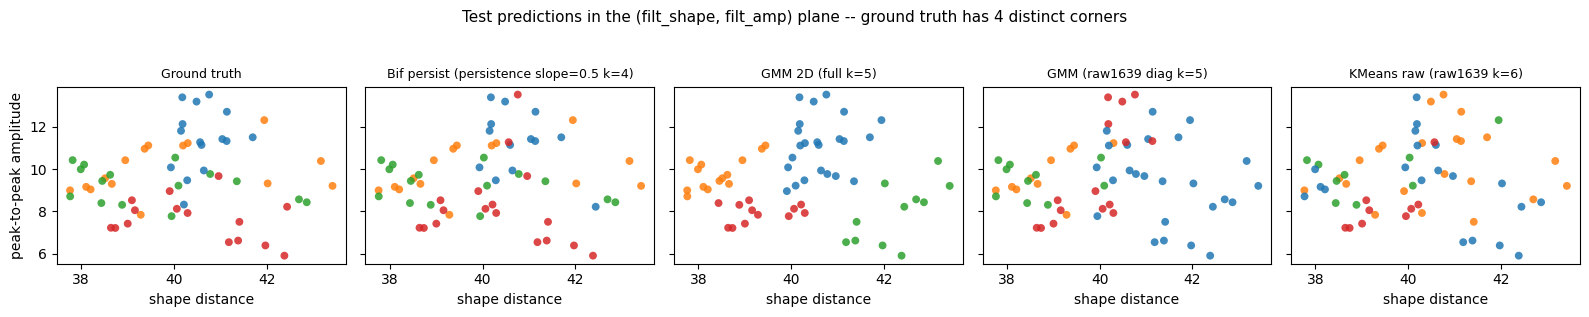

In [5]:
res_by_name = {r["method"]: r for r in results}

PRED_COLORS = ["C0", "C1", "C2", "C3"]

methods_to_show = [
    ("Ground truth", y_true),
    (f"Bif persist ({res_by_name['Bifiltration (persist)']['best_config']})",
     res_by_name["Bifiltration (persist)"]["pred"]),
    (f"GMM 2D ({res_by_name['GMM 2D']['best_config']})",
     res_by_name["GMM 2D"]["pred"]),
    (f"GMM ({res_by_name['GMM']['best_config']})",
     res_by_name["GMM"]["pred"]),
    (f"KMeans raw ({res_by_name['KMeans']['best_config']})",
     res_by_name["KMeans"]["pred"]),
]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(16, 3.0),
                         sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, methods_to_show):
    aligned, _ = align_hungarian(np.asarray(labels), y_true)
    colors = [PRED_COLORS[(int(a) - 1) % K_TRUE] for a in aligned[test_idx]]
    ax.scatter(shape_dist[test_idx], amp[test_idx],
               c=colors, s=32, alpha=0.85, edgecolors="none")
    ax.set_title(name, fontsize=9); ax.set_xlabel("shape distance")
axes[0].set_ylabel("peak-to-peak amplitude")
fig.suptitle("Test predictions in the (filt_shape, filt_amp) plane "
             "-- ground truth has 4 distinct corners",
             y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

## Series grouped by ground-truth class

Each row is one method. Columns are the 4 ground-truth classes
(test set, 10 records each). Lines coloured by predicted cluster.
The best method paints each panel one colour.

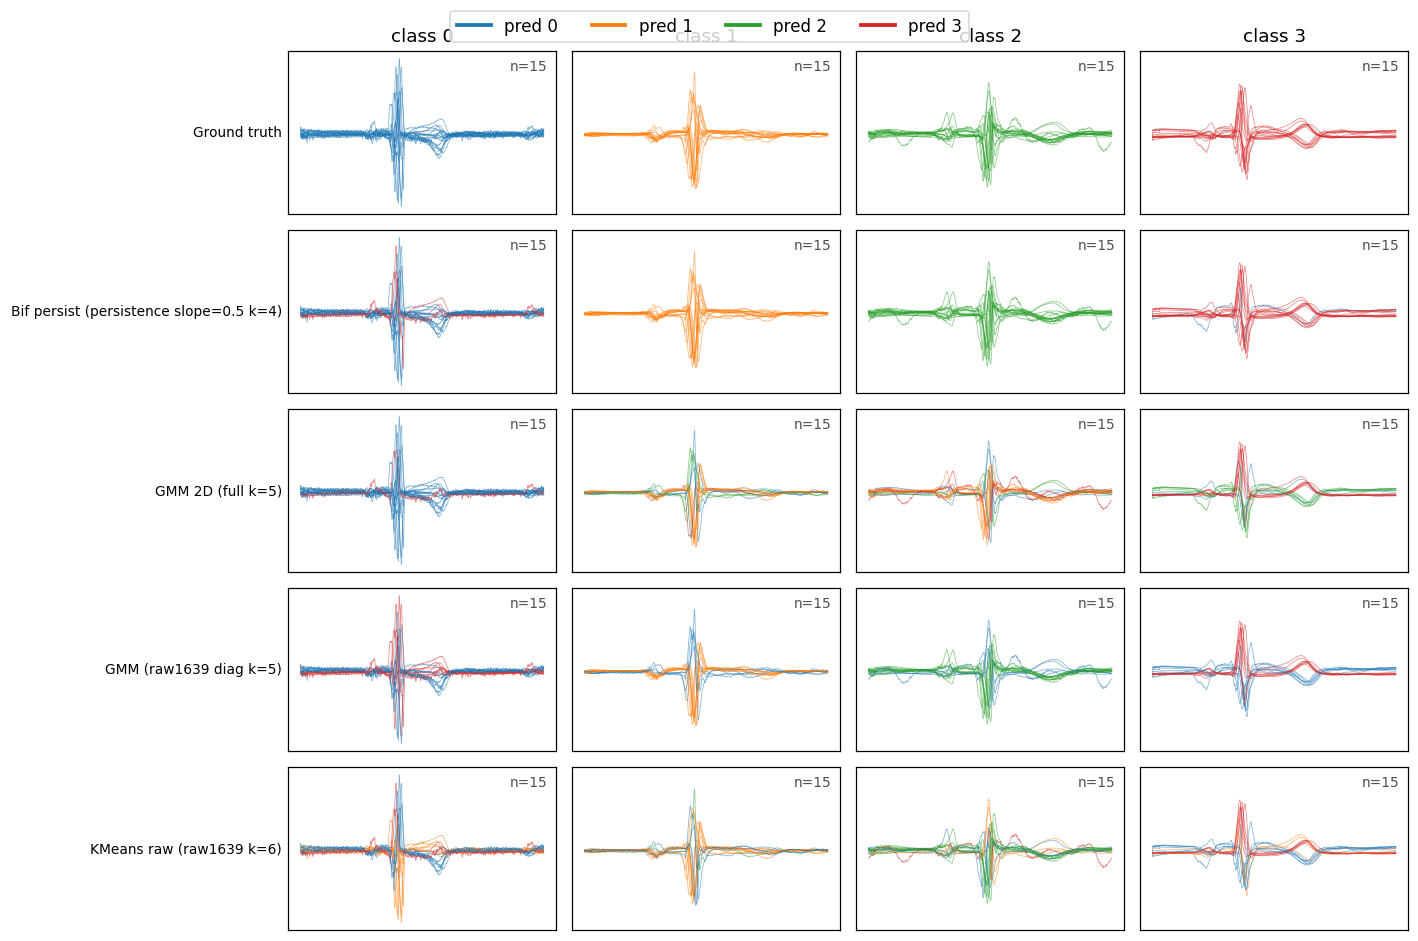

In [6]:
fig, axes = plt.subplots(len(methods_to_show), K_TRUE,
                         figsize=(13, 1.7 * len(methods_to_show)),
                         sharex=True, sharey=True, dpi=110)
for row, (name, labels) in enumerate(methods_to_show):
    aligned, _ = align_hungarian(np.asarray(labels), y_true)
    for col in range(K_TRUE):
        ax = axes[row, col]
        idxs = test_idx[y_true[test_idx] == col]
        for i in idxs:
            ax.plot(X[i], color=PRED_COLORS[(aligned[i] - 1) % K_TRUE], lw=0.5, alpha=0.55)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.95, f"n={len(idxs)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="0.3")
        if row == 0: ax.set_title(f"class {col}", fontsize=12)
        if col == 0: ax.set_ylabel(name, fontsize=9, rotation=0, ha="right", va="center")

handles = [plt.Line2D([0], [0], color=PRED_COLORS[c], lw=2.5, label=f"pred {c}")
           for c in range(K_TRUE)]
fig.legend(handles=handles, loc="upper center", ncol=K_TRUE,
           bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout(); plt.show()